# NB09aV3: Dietrich RF Baseline + Ablation v2 (V3 per-point sample unit)

> Copyright (C) 2024-2026 Marco Heinzen - SPDX-License-Identifier: AGPL-3.0-or-later
> Part of the Master Thesis "Building Damage Assessment with Multimodal Satellite Time Series and Machine Learning in the Russia-Ukraine War 2022-2026"
> Code hosted at https://github.com/marcoheinzen/bda
> Parts of this code were written or improved with the assistance of Claude (Anthropic); all other code, and the concept, research, architecture, design, execution, testing and validation throughout, are the author's work.



| Field | Value |
|---|---|
| Notebook | `09aV3_BDA_Dietrich_RF_Baseline_v2.ipynb` |
| Version | `NB09aV3 v2` |
| Pipeline position | Per-point baseline + ablation on V3 dietrich28 features. |
| Last updated | `2026-05-06` |

## What changed in v2

The `filter_dietrich28()` function has been corrected. The v1 implementation was written for the V2 footprint column format `s1__{pol}__{block}__{stat}_{zonal_agg}` and applied a `zonal_agg == 'mean'` check that silently dropped 6 of 7 stats from V3 columns (which use single-suffix format `s1__{pol}__{block}__{stat}`). All v1 numbers in this notebook reflect a 38-feature subset (mean only) instead of Dietrich's full 7-stat set (~270 features).

The corrected filter auto-detects column format and applies the correct logic to each. Re-running this notebook from scratch produces apples-to-apples Dietrich-faithful baselines on V3.

## Action required

Re-run all cells from CELL S0 onward. Saved OOFs from v1 in the registry remain untouched (different `notebook` tag); v2 results will be saved alongside under `NB09aV3_v2`.

In [1]:
# @title CELL 3: NB09aV3 CONFIG
TIER_SELECTION = [0,1,2]
CITY_FILTER = None
CITY_SELECTION = None
REQUIRE_UNOSAT = True
RANDOM_STATE = 42
N_FOLDS = 5

# v2 parquet system (manifest-driven). Set to False to fall back to v1 paths.
USE_V2 = True

In [2]:
# @title CELL 4: LOAD GLOBAL SETUP
import platform, os, json
if platform.system() == "Windows":
    _setup = r"F:\PROJECTS\masterthesis\gdrive\masterthesis\notebooks\global_setup.py"
elif os.path.exists("/content/drive_f"):
    _setup = "/content/drive_f/masterthesis/notebooks/global_setup.py"
else:
    _setup = "/mnt/f/PROJECTS/masterthesis/gdrive/masterthesis/notebooks/global_setup.py"
with open(_setup) as f:
    exec(f.read())

BDA GLOBAL SETUP
Started: 2026-05-06 14:28:12
Python: 3.12.12

[1/7] Directory Structure
----------------------------------------------------------------------


/home/alpineobotics/miniconda3/envs/bda/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


  GDrive (G:):       /content/drive_f/masterthesis OK
  GDrive (F:):       /content/drive_f/masterthesis OK
  Local data (G:):   /content/masterthesis_local/data OK
  Data stack (F:):   /mnt/f/PROJECTS/masterthesis/data_stack OK

  TIER_SELECTION: [0, 1, 2]
  CITY_SELECTION: None (tier filter)
  REQUIRE_UNOSAT: True
  CITIES_TO_PROCESS: 21 cities

[2/7] Credentials
----------------------------------------------------------------------
  Copernicus: inf***
  OpenTopography: OK
  Earthdata: marcoheinzen

[3/7] Python Packages
----------------------------------------------------------------------


<string>:564: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.



  Already installed: 23
  Newly installed:   0
  Failed:            0

[4/7] Global Imports & Configuration
----------------------------------------------------------------------
  All imports loaded

[5/7] Processing Config & SNAP
----------------------------------------------------------------------
  GPT: Usage:
  Temporal baseline: 10-24 days
  Wavelength: 0.0555

[6/7] GPU Status
----------------------------------------------------------------------
  CUDA available: NVIDIA GeForce RTX 2070 SUPER
    CUDA version: 12.8

[7/7] Disk Space
----------------------------------------------------------------------
  GDrive (G:)     910.6/7452.0 GB (6541.4 GB free)
  GDrive (F:)     1407.9/3726.0 GB (2318.1 GB free)
  Local data      11559.3/14901.9 GB (3342.6 GB free)
  Data stack      1407.9/3726.0 GB (2318.1 GB free)
  WSL ext4        68.6/1006.9 GB (887.1 GB free)

GLOBAL SETUP COMPLETE
  Torch device: cuda
  Cities: 21, CITY=Avdiivka
  Functions: load_aoi(), load_aoi_gdf(), load_aoi_

# CELL S0: LOAD MANIFEST + BUILDINGS + SHARED HELPERSLoads v2 parquet manifest, building metadata, defines `load_v2()` loader that readsone parquet per call with columns filter, merges with buildings. Every downstreamR-cell calls `load_v2(manifest_key)` then does `del df; gc.collect()` at end.

In [3]:
# @title CELL S0: LOAD MANIFEST + POINTS + SHARED HELPERS
import sys, importlib, re, gc, time
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import GroupKFold, StratifiedKFold
from sklearn.metrics import (roc_auc_score, f1_score, precision_score,
                             recall_score, precision_recall_curve, roc_curve)
from sklearn.impute import SimpleImputer
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

print("=" * 70)
print("CELL S0: NB09aV3 v1 — LOAD MANIFEST + BUILDINGS + SHARED HELPERS")
print("=" * 70)

if str(NOTEBOOKS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS_DIR))

# --- load V3 manifest -------------------------------------------------
# V3 dataset path (not in global_setup.py which only defines V2)
DATASET_ROOT_V3 = STACK_DIR / 'dataset' / 'v3'
MANIFEST_V3_PATH = DATASET_ROOT_V3 / 'parquet_manifest.json'
if not MANIFEST_V3_PATH.exists():
    raise FileNotFoundError(f"V3 manifest not found: {MANIFEST_V3_PATH}")
with open(MANIFEST_V3_PATH) as _f:
    MANIFEST = json.load(_f)
print(f"  Manifest: {MANIFEST_V3_PATH}")
print(f"  Version: {MANIFEST['version']}  Created: {MANIFEST['created']}")
print(f"  Parquets in manifest: {len(MANIFEST['parquets'])}")

# --- load point metadata (V3 path) --------------------------------
_tiers = TIER_SELECTION if isinstance(TIER_SELECTION, list) else [0, 1, 2]
_bldg_pattern = str(DATASET_ROOT_V3 / 'bda_points_t{tier}.parquet')
df_bldg = load_tier_parquets(_bldg_pattern, _tiers)
CITIES_TO_PROCESS, _battle_dates = resolve_cities(
    tier_selection=TIER_SELECTION,
    city_selection=[CITY_FILTER] if isinstance(CITY_FILTER, str) else CITY_FILTER,
    require_unosat=REQUIRE_UNOSAT,
)
df_bldg = df_bldg[df_bldg['city'].isin(CITIES_TO_PROCESS)].copy()
df_bldg = df_bldg[df_bldg['damage_binary'] >= 0].copy()
print(f"  Cities: {len(CITIES_TO_PROCESS)}")
print(f"  Points: {len(df_bldg)} (damaged={int((df_bldg['damage_binary']==1).sum())}, undamaged={int((df_bldg['damage_binary']==0).sum())})")

TARGET_COL = 'damage_binary'
EXPERIMENT_LOG = {}
DIETRICH_PAPER = {'auc': 0.813, 'f1': 0.749, 'precision': 0.671, 'recall': 0.846}

# ---- NB12 overlap-analysis: canonical OOF predictions schema ----
import hashlib as _hashlib, datetime as _dt
EXPERIMENT_ID = _dt.datetime.now().strftime('%Y%m%d_%H%M%S') + '_' + _hashlib.md5(
    f'nb09a_{TIER_SELECTION}_{REQUIRE_UNOSAT}'.encode()).hexdigest()[:6]
print(f"  EXPERIMENT_ID: {EXPERIMENT_ID}")

def save_oof_from_result(res, model_id, oof_dir, variant_id='',
                         is_final=False, threshold=0.5):
    '''Canonical OOF schema from a result dict that contains:
       y_true, y_proba, groups, building_id, fold_id (all same length, valid-masked).'''
    if res is None:
        return None
    needed = ('y_true', 'y_proba', 'groups', 'point_id', 'fold_id')
    if not all(k in res for k in needed):
        print(f"    [save_oof] skipped {model_id}: missing keys (need {needed})")
        return None
    y_proba = np.asarray(res['y_proba'])
    yt = np.asarray(res['y_true']).astype(int)
    fold = np.asarray(res['fold_id']).astype(int)
    bid = np.asarray(res['point_id'])
    cty = np.asarray(res['groups'])
    yp = (y_proba >= threshold).astype(int)
    cm_class = np.where(yt == 1,
                        np.where(yp == 1, 'TP', 'FN'),
                        np.where(yp == 1, 'FP', 'TN'))
    oof_df = pd.DataFrame({
        'point_id':   bid,
        'city':          cty,
        'fold_id':       fold,
        'y_true':        yt,
        'y_proba':       y_proba.astype(float),
        'y_pred':        yp,
        'cm_class':      cm_class,
        'model_id':      model_id,
        'experiment_id': EXPERIMENT_ID,
        'variant_id':    variant_id,
        'is_final':      bool(is_final),
    })
    oof_dir = Path(oof_dir)
    oof_dir.mkdir(parents=True, exist_ok=True)
    out = oof_dir / f'oof_{model_id}__{EXPERIMENT_ID}.parquet'
    oof_df.to_parquet(out, index=False)
    n_tp = int((cm_class == 'TP').sum()); n_fn = int((cm_class == 'FN').sum())
    n_fp = int((cm_class == 'FP').sum()); n_tn = int((cm_class == 'TN').sum())
    print(f"    saved oof -> {out.name}  TP={n_tp} FN={n_fn} FP={n_fp} TN={n_tn}")
    return out

# --- metadata filter: single source of truth for leakage exclusion ----
# Previous hardcoded LEAKAGE_EXCLUDE_PATTERNS (4 patterns) covered only a
# subset of leakage vectors -- missing was_observed_*, s1__vv__scenes_observed,
# s2__scenes_observed, s2__lu__scenes_observed, s2__visibility__{fire,smoke,
# clear}__freq, block __count_*, rolling __count_*, and the full dietrich
# pixel-count family. metadata_filter.is_non_feature() catches all of them
# via pattern rules and a name-based metadata whitelist.
import importlib
import metadata_filter
importlib.reload(metadata_filter)
from metadata_filter import is_non_feature

def drop_leakage(cols):
    # Thin wrapper so existing prepare_features() and experiment cells keep
    # working. Strictly MORE restrictive than the old 4-pattern filter.
    return [c for c in cols if not is_non_feature(c)]

# --- Dietrich-28 stat filter (NOT a metadata leak filter) ------------
# Used by filter_dietrich28() to exclude the 'count' stat from the
# Dietrich-28 feature subset. Separate concern from metadata leakage:
# this is about matching Dietrich et al. 2025's replication spec.
EXCLUDE_CARD_STATS = ['count']

# --- dietrich column filter (from NB07 D1b, proven to work) ----------
def filter_dietrich28(cols):
    """Auto-detect column format and keep Dietrich's 7 backscatter stats.

    Stats kept: min, max, mean, median, std, kurtosis, skewness.
    Stats excluded: count (metadata) and accumulator stats (drop_count,
    rise_count, max_abs_delta, running_min, running_max).

    V2 footprint format: s1__{pol}__{block}__{stat}_{zonal_agg}
        e.g. s1__vh__blk01__std_mean (std temporal, mean zonal aggregation).
        Only zonal_agg='mean' is kept.

    V3 per-pixel and V4 3x3-kernel format: s1__{pol}__{block}__{stat}
        e.g. s1__vh__blk01__std (std only, no zonal aggregation).
        All 7 stats are kept directly.

    Note: prior versions of this function dropped 6 of 7 stats from V3 because
    the V2-style zonal_agg check was applied to V3 columns that have no zonal
    suffix. With V3 dietrich28 returning only ~38 columns instead of ~270,
    per-row feature richness was 14% of Dietrich's. Fix made on 2026-05-06.
    """
    DIETRICH_STATS = {'min', 'max', 'mean', 'median', 'std', 'kurtosis', 'skewness'}
    out = []
    for c in cols:
        parts = c.split('__')
        if len(parts) < 4:
            continue
        stat_agg = parts[3]
        if '_' in stat_agg:
            # V2 footprint: stat_temporal_stat_zonal
            stat_name, zonal_agg = stat_agg.rsplit('_', 1)
            if zonal_agg != 'mean':
                continue
        else:
            # V3 per-pixel or V4 3x3-kernel: single stat suffix, no zonal
            stat_name = stat_agg
        if stat_name not in DIETRICH_STATS:
            continue
        if stat_name in EXCLUDE_CARD_STATS:
            continue
        out.append(c)
    return out
def load_v2(manifest_key, tiers=None, columns=None, sample_frac=None):
    '''Load a v2 parquet by manifest key, merge with buildings, return df.'''
    if manifest_key not in MANIFEST['parquets']:
        raise KeyError(f"Manifest key not found: {manifest_key}")
    info = MANIFEST['parquets'][manifest_key]
    fname_tmpl = Path(info['pattern']).name
    tiers = tiers if tiers is not None else _tiers

    frames = []
    for t in tiers:
        pf = DATASET_ROOT_V3 / fname_tmpl.format(tier=t)
        if not pf.exists():
            print(f"  WARNING: {pf.name} not found, skipping tier {t}")
            continue
        if columns is not None:
            join_cols = info.get('join_keys', ['city', 'point_id'])
            read_cols = list(dict.fromkeys(join_cols + list(columns)))
            try:
                df_t = pd.read_parquet(pf, columns=read_cols)
            except Exception:
                df_t = pd.read_parquet(pf)
                keep = [c for c in read_cols if c in df_t.columns]
                df_t = df_t[keep]
        else:
            df_t = pd.read_parquet(pf)
        if sample_frac is not None and 0 < sample_frac < 1:
            df_t = df_t.sample(frac=sample_frac, random_state=RANDOM_STATE)
        frames.append(df_t)
    if not frames:
        raise FileNotFoundError(f"No v2 parquets found for key={manifest_key} tiers={tiers}")
    df = pd.concat(frames, ignore_index=True)
    del frames

    df = df.loc[:, ~df.columns.duplicated()]
    df = df[df['city'].isin(CITIES_TO_PROCESS)].copy()
    if TARGET_COL not in df.columns:
        df = df.merge(df_bldg[['point_id', 'city', TARGET_COL]].drop_duplicates(),
                      on=['point_id', 'city'], how='inner')
    df = df[df[TARGET_COL] >= 0].copy()
    df = df.loc[:, ~df.columns.duplicated()]
    print(f"  load_v2('{manifest_key}'): {len(df):,} rows, {df.shape[1]} cols, {df['city'].nunique()} cities")
    return df

# --- legacy v1 loader kept intact (some cells may still use it) ------
def load_and_merge(parquet_fmt, **kwargs):
    """V1 loader: load per-tier v1 parquets by path fmt, merge with buildings."""
    if isinstance(parquet_fmt, Path) and parquet_fmt.exists():
        df = pd.read_parquet(parquet_fmt)
    else:
        df = load_tier_parquets(str(parquet_fmt), _tiers, **kwargs)
    df = df[df['city'].isin(CITIES_TO_PROCESS)].copy()
    if TARGET_COL not in df.columns:
        df = df.merge(df_bldg[['point_id', 'city', TARGET_COL]].drop_duplicates(),
                      on=['point_id', 'city'], how='inner')
    df = df[df[TARGET_COL] >= 0].copy()
    return df

# --- feature prep + evaluation helpers (unchanged from v20) ----------
def prepare_features(df, feat_cols, drop_all_nan=True):
    """Extract X, y, groups from df, drop all-NaN columns, median-impute."""
    feat_cols = [c for c in feat_cols if c in df.columns]
    feat_cols = drop_leakage(feat_cols)
    if not feat_cols:
        print(f"    SKIP: no non-leakage feature columns")
        return None
    if drop_all_nan:
        nan_rate = df[feat_cols].isna().mean()
        feat_cols = [c for c in feat_cols if nan_rate[c] < 1.0]
    if len(feat_cols) < 2:
        print(f"    SKIP: {len(feat_cols)} feature columns after NaN drop")
        return None
    X = df[feat_cols].values
    y = df[TARGET_COL].values
    groups = df['city'].values
    building_ids = df['point_id'].values
    imp = SimpleImputer(strategy='median')
    X = imp.fit_transform(X)
    return X, y, groups, building_ids, feat_cols


def evaluate_groupkfold(clf, X, y, groups, experiment_name, n_folds=N_FOLDS, needs_scaling=False,
                        building_ids=None):
    n_cities = len(np.unique(groups))
    n_folds_actual = min(n_folds, n_cities)
    if n_folds_actual < 2:
        print(f"    SKIP {experiment_name}: only {n_cities} cities")
        return None
    gkf = GroupKFold(n_splits=n_folds_actual)
    y_proba_oof = np.full(len(y), np.nan)
    fold_id = np.full(len(y), -1, dtype=int)
    fold_aucs = []
    for fold_idx, (tr, te) in enumerate(gkf.split(X, y, groups)):
        Xtr, Xte = X[tr], X[te]
        ytr, yte = y[tr], y[te]
        if needs_scaling:
            scaler = StandardScaler()
            Xtr = scaler.fit_transform(Xtr); Xte = scaler.transform(Xte)
        clf_c = clone(clf)
        clf_c.fit(Xtr, ytr)
        proba = clf_c.predict_proba(Xte)[:, 1] if hasattr(clf_c, 'predict_proba') else 1.0 / (1.0 + np.exp(-clf_c.decision_function(Xte)))
        y_proba_oof[te] = proba
        fold_id[te] = fold_idx
        if len(np.unique(yte)) > 1:
            fold_aucs.append(roc_auc_score(yte, proba))
    valid = ~np.isnan(y_proba_oof)
    y_v, p_v = y[valid], y_proba_oof[valid]
    pred_v = (p_v >= 0.5).astype(int)
    bid_v = np.asarray(building_ids)[valid] if building_ids is not None else np.arange(len(y))[valid].astype(str)
    result = {
        'experiment': experiment_name,
        'auc_groupkfold': roc_auc_score(y_v, p_v),
        'f1_groupkfold': f1_score(y_v, pred_v),
        'precision': precision_score(y_v, pred_v, zero_division=0),
        'recall': recall_score(y_v, pred_v, zero_division=0),
        'fold_aucs': fold_aucs,
        'auc_mean': float(np.mean(fold_aucs)) if fold_aucs else float('nan'),
        'auc_std': float(np.std(fold_aucs)) if fold_aucs else float('nan'),
        'n_features': X.shape[1], 'n_buildings': len(y), 'n_cities': len(np.unique(groups)),
        'y_true': y_v, 'y_proba': p_v, 'groups': groups[valid],
        'point_id': bid_v, 'fold_id': fold_id[valid],
    }
    EXPERIMENT_LOG[experiment_name] = result
    print(f"    {experiment_name:45s} AUC={result['auc_groupkfold']:.3f}  F1={result['f1_groupkfold']:.3f}  n={valid.sum():,} cities={result['n_cities']}")
    return result


# --- result logging / output paths -----------------------------------
import matplotlib.pyplot as plt
from datetime import datetime as _dt

OUT_DIR = OUTPUTS_DIR / "NB09aV3_v1"
OUT_DIR.mkdir(parents=True, exist_ok=True)


def save_result(data, name, cell_id, fmt='csv'):
    cell_dir = OUT_DIR / cell_id
    cell_dir.mkdir(parents=True, exist_ok=True)
    ts = _dt.now().strftime('%Y%m%d_%H%M%S')
    if fmt == 'csv' and isinstance(data, pd.DataFrame):
        path = cell_dir / f"{name}_{ts}.csv"
        data.to_csv(path, index=False)
    elif fmt == 'json':
        path = cell_dir / f"{name}_{ts}.json"
        with open(path, 'w') as fh:
            json.dump(data, fh, indent=2, default=str)
    else:
        raise ValueError(f"Unknown fmt={fmt}")
    print(f"  Saved: {path.relative_to(OUT_DIR)} ({path.stat().st_size / 1024:.1f} KB)")
    return path


def save_fig(fig, name, cell_id, dpi=150):
    cell_dir = OUT_DIR / cell_id
    cell_dir.mkdir(parents=True, exist_ok=True)
    ts = _dt.now().strftime('%Y%m%d_%H%M%S')
    path = cell_dir / f"{name}_{ts}.png"
    fig.savefig(path, dpi=dpi, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"  Plot: {path.relative_to(OUT_DIR)}")
    return path


from bda_results import ResultRegistry
registry = ResultRegistry(RESULTS_ROOT, notebook='NB09aV3_v1')


def log_result(res, cell_id, parquet_name, feature_set_name, feature_cols,
               classifier_name='RF-200', classifier_params=None, cv_method='GroupKFold',
               note='', tags=None):
    if res is None:
        return
    registry.log_experiment(
        cell_id=cell_id, experiment_name=res['experiment'],
        parquet_name=parquet_name, feature_set_name=feature_set_name,
        classifier_name=classifier_name, classifier_params=classifier_params or {},
        feature_cols=feature_cols, cv_method=cv_method, n_folds=N_FOLDS,
        imputation='median', y_true=res['y_true'], y_proba=res['y_proba'],
        groups=res['groups'], note=note, tags=tags or [],
    )


print(f"  Helpers: load_v2(), load_and_merge(), prepare_features(), evaluate_groupkfold()")
print(f"  Output:  {OUT_DIR}")
print(f"  Registry: NB09aV3_v1")

CELL S0: NB09aV3 v1 — LOAD MANIFEST + BUILDINGS + SHARED HELPERS
  Manifest: /mnt/f/PROJECTS/masterthesis/data_stack/dataset/v3/parquet_manifest.json
  Version: v3  Created: 2026-04-26T22:51:55.230070
  Parquets in manifest: 36
  load_tier_parquets: 3 tiers, 63243 rows
  Cities: 21
  Points: 63243 (damaged=8247, undamaged=54996)
  EXPERIMENT_ID: 20260506_142934_7bcb82
  ResultRegistry: /content/drive_f/masterthesis/results/registry (run_id=20260506_142934)
  Helpers: load_v2(), load_and_merge(), prepare_features(), evaluate_groupkfold()
  Output:  /content/drive_f/masterthesis/data/outputs/NB09aV3_v1
  Registry: NB09aV3_v1


In [4]:
# @title CELL S0b: OOF PLOT + SUMMARY HELPERS
# TP=red, TN=green, FP=pink, FN=gold
import matplotlib.pyplot as plt

CM_COLORS = {'TP': '#d62728', 'TN': '#2ca02c', 'FP': '#ff9ecb', 'FN': '#ffd700'}
CM_LABELS = {'TP': 'Destroyed (TP)', 'TN': 'Not destroyed (TN)',
             'FP': 'False positive (FP)', 'FN': 'False negative (FN)'}

# alias df_bldg -> df_points for plotting helper compatibility
df_points = df_bldg

def print_cm_summary(oof_path_or_df):
    if isinstance(oof_path_or_df, (str, Path)):
        oof = pd.read_parquet(oof_path_or_df)
    else:
        oof = oof_path_or_df
    model_id = oof['model_id'].iloc[0] if 'model_id' in oof.columns else '(unknown)'
    print(f"  model_id: {model_id}   n={len(oof)}")
    overall = oof['cm_class'].value_counts()
    for cls in ['TP', 'TN', 'FP', 'FN']:
        n = int(overall.get(cls, 0))
        pct = 100.0 * n / len(oof) if len(oof) else 0
        print(f"    {cls:3s} {CM_LABELS[cls]:28s}  n={n:6d}  ({pct:5.1f}%)")
    by_city = (oof.groupby('city')['cm_class']
                 .value_counts().unstack(fill_value=0))
    for cls in ['TP', 'TN', 'FP', 'FN']:
        if cls not in by_city.columns:
            by_city[cls] = 0
    by_city = by_city[['TP', 'TN', 'FP', 'FN']]
    by_city['recall']    = by_city['TP'] / (by_city['TP'] + by_city['FN']).replace(0, np.nan)
    by_city['precision'] = by_city['TP'] / (by_city['TP'] + by_city['FP']).replace(0, np.nan)
    print(f"\n  Per-city:")
    print(by_city.to_string(float_format=lambda x: f'{x:.3f}' if pd.notna(x) else '-'))
    return by_city

def plot_cm_spatial(oof_path_or_df, save_name=None, figsize=(14, 10),
                    buildings_df=None, point_size=4):
    if isinstance(oof_path_or_df, (str, Path)):
        oof = pd.read_parquet(oof_path_or_df)
    else:
        oof = oof_path_or_df
    bdf = buildings_df if buildings_df is not None else df_points
    # V3: use x_utm/y_utm as primary coordinates; fall back to centroid_x/y (V2)
    if 'x_utm' in bdf.columns and 'y_utm' in bdf.columns:
        _cx, _cy = 'x_utm', 'y_utm'
    elif 'centroid_x' in bdf.columns and 'centroid_y' in bdf.columns:
        _cx, _cy = 'centroid_x', 'centroid_y'
    else:
        print("  plot_cm_spatial: no coordinate columns (x_utm/centroid_x)")
        return None
    plot_df = oof.merge(bdf[['point_id', 'city', _cx, _cy]],
                        on=['point_id', 'city'], how='inner')
    if len(plot_df) == 0:
        print("  plot_cm_spatial: no building matches")
        return None
    cities = sorted(plot_df['city'].unique())
    ncols = min(3, len(cities))
    nrows = (len(cities) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, squeeze=False)
    model_id = oof['model_id'].iloc[0] if 'model_id' in oof.columns else ''
    fig.suptitle(f'Confusion-matrix map: {model_id}', fontsize=11)
    draw_order = ['TN', 'FP', 'FN', 'TP']
    for i, city in enumerate(cities):
        ax = axes[i // ncols][i % ncols]
        cdf = plot_df[plot_df['city'] == city]
        for cls in draw_order:
            pts = cdf[cdf['cm_class'] == cls]
            if len(pts) == 0:
                continue
            ax.scatter(pts[_cx], pts[_cy],
                       c=CM_COLORS[cls], s=point_size, alpha=0.75,
                       edgecolors='none',
                       label=f"{CM_LABELS[cls]} (n={len(pts)})")
        ax.set_title(f"{city}  (n={len(cdf)})", fontsize=9)
        ax.set_aspect('equal')
        ax.legend(loc='best', fontsize=6, markerscale=2, framealpha=0.85)
        ax.tick_params(labelsize=7)
    for j in range(len(cities), nrows * ncols):
        axes[j // ncols][j % ncols].axis('off')
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    if save_name:
        fig.savefig(OUT_DIR / f'{save_name}.png', dpi=150, bbox_inches='tight')
        plt.close(fig)
    return fig

def plot_cm_oof_all(oof_dir, skip_variants=()):
    d = Path(oof_dir)
    files = sorted(d.glob('oof_*.parquet'))
    print(f"  Found {len(files)} OOF parquets in {d}")
    for p in files:
        oof = pd.read_parquet(p)
        v = oof['variant_id'].iloc[0] if 'variant_id' in oof.columns else ''
        if any(sv in v for sv in skip_variants):
            print(f"  skip {p.name}  (variant_id={v})")
            continue
        print(f"\n  {p.name}")
        print_cm_summary(oof)
        plot_cm_spatial(oof, save_name=p.stem)


# CELL H: CLASSIFIER PARAMS + HELPERS

In [5]:
# @title CELL H: CLASSIFIER PARAMS + HELPERS
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                               GradientBoostingClassifier)

RF_PARAMS = {'n_estimators': 200, 'min_samples_leaf': 3, 'random_state': RANDOM_STATE,
             'n_jobs': -1, 'class_weight': 'balanced'}

CLASSIFIERS = {
    'RF-200': RandomForestClassifier(**RF_PARAMS),
    'ExtraTrees': ExtraTreesClassifier(n_estimators=200, min_samples_leaf=3,
                                        random_state=RANDOM_STATE, n_jobs=-1, class_weight='balanced'),
    'GBM': GradientBoostingClassifier(n_estimators=200, max_depth=5, learning_rate=0.1,
                                       random_state=RANDOM_STATE),
}

try:
    from lightgbm import LGBMClassifier
    CLASSIFIERS['LightGBM'] = LGBMClassifier(n_estimators=200, max_depth=7, learning_rate=0.1,
                                              random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
                                              is_unbalance=True)
except ImportError:
    print("  LightGBM not available")

try:
    from xgboost import XGBClassifier
    CLASSIFIERS['XGBoost'] = XGBClassifier(n_estimators=200, max_depth=7, learning_rate=0.1,
                                            random_state=RANDOM_STATE, n_jobs=-1, verbosity=0,
                                            scale_pos_weight=1, use_label_encoder=False, eval_metric='logloss')
except ImportError:
    print("  XGBoost not available")

print(f"  Classifiers: {list(CLASSIFIERS.keys())}")

  Classifiers: ['RF-200', 'ExtraTrees', 'GBM', 'LightGBM', 'XGBoost']


In [6]:
def f8_feature_groups(df):
    """Modality subsets of fusion_composite_blockstats F8 columns.
    Conventions:
      CARD  = s1__ (excluding s1__coh)
      COH   = s1__coh
      MS    = s2__
    """
    cols = list(df.columns)
    card = [c for c in cols if c.startswith('s1__') and not c.startswith('s1__coh')]
    coh  = [c for c in cols if c.startswith('s1__coh')]
    ms   = [c for c in cols if c.startswith('s2__')]

    groups = {
        'card_only':       drop_leakage(card),
        'coh_only':        drop_leakage(coh),
        'ms_only':         drop_leakage(ms),
        'card_coh':        drop_leakage(card + coh),
        'card_ms':         drop_leakage(card + ms),
        'coh_ms':          drop_leakage(coh + ms),
        'all_multimodal':  drop_leakage(card + coh + ms),
    }
    return groups

# CELL R0: FAITHFUL DIETRICH REPLICATION (V3 `block_stats` A15)baseline + blk01 with 7 stats × 2 pols × _mean zonal aggregate = 28 features.Pooled GroupKFold across all cities. This is the closest possible Dietrichreplication with our v2 architecture. Column selection logic is identical toNB07 D1b (proven to produce the correct 28-feature set).

In [7]:
# @title CELL R0: FAITHFUL DIETRICH REPLICATION (block_stats A15, baseline+blk01)
from stack_loader import get_feature_groups

print("=" * 70)
print("CELL R0: FAITHFUL DIETRICH (baseline + blk01, 28 features)")
print("=" * 70)

df_blk = load_v2('block_stats')
feature_groups = get_feature_groups(df_blk)
print(f"  Feature groups discovered: {len([g for g in feature_groups if g != 'meta'])}")

all_card_cols = [c for c in df_blk.columns
                 if c.startswith('s1__') and not c.startswith('s1__coh')]
baseline_cols = [c for c in all_card_cols if '__baseline__' in c]
blk01_cols = [c for c in all_card_cols if '__blk01__' in c]

d28_baseline = filter_dietrich28(baseline_cols)
d28_blk01 = filter_dietrich28(blk01_cols)
dietrich28_cols = d28_baseline + d28_blk01

print(f"  Dietrich-28 baseline (T0-equivalent): {len(d28_baseline)}")
print(f"  Dietrich-28 blk01 (first post-invasion block): {len(d28_blk01)}")
print(f"  Total features: {len(dietrich28_cols)}")

result = prepare_features(df_blk, dietrich28_cols)
if result:
    X, y, groups, building_ids, clean = result
    rf = RandomForestClassifier(**RF_PARAMS)
    res = evaluate_groupkfold(rf, X, y, groups, "R0_dietrich28_faithful_groupkfold",
                              building_ids=building_ids)
    log_result(res, cell_id='cell_r0', parquet_name='bda_block_stats_v2',
               feature_set_name='dietrich28_baseline_blk01', feature_cols=clean,
               note='Faithful Dietrich 2025 replication: baseline + blk01, 7 stats x 2 pols x _mean zonal',
               tags=['dietrich', 'faithful', 'block_stats'])
    print(f"\n  Dietrich paper (4 train / 14 test cities): AUC={DIETRICH_PAPER['auc']}, F1={DIETRICH_PAPER['f1']}")
    print(f"  Our GroupKFold across {res['n_cities']} cities: AUC={res['auc_groupkfold']:.3f}")
    save_result(pd.DataFrame([{k: v for k, v in res.items()
                                if k not in ('y_true','y_proba','groups','fold_aucs')}]),
                'dietrich28_faithful', 'cell_r0')

del df_blk
gc.collect()

CELL R0: FAITHFUL DIETRICH (baseline + blk01, 28 features)
  load_v2('block_stats'): 63,243 rows, 334 cols, 21 cities
  Feature groups discovered: 20
  Dietrich-28 baseline (T0-equivalent): 14
  Dietrich-28 blk01 (first post-invasion block): 14
  Total features: 28
    R0_dietrich28_faithful_groupkfold             AUC=0.545  F1=0.005  n=63,243 cities=21
  REG: R0_dietrich28_faithful_groupkfold             AUC=0.5455 F1=0.0051 n=63243 feat=28 cities=21 [NB09aV3_v1/cell_r0]

  Dietrich paper (4 train / 14 test cities): AUC=0.813, F1=0.749
  Our GroupKFold across 21 cities: AUC=0.545
  Saved: cell_r0/dietrich28_faithful_20260506_142952.csv (0.5 KB)


48

# CELL R0a: DIETRICH ALL BLOCKS + Eq.3 MAX AGGREGATIONTrain one RF per post-invasion block (blk01..blk16), predict per block, take`max(post_probas)` per building. Apply pre-invasion guard via `blk_pre01`:damaged if `max(post) >= threshold AND max(pre) < threshold`. This is DietrichEq.3. V2 has 16 post blocks + 1 pre block (paper has 8 + 4).

In [8]:
# @title CELL R0a: DIETRICH ALL BLOCKS + Eq.3 MAX AGGREGATION (block_stats A15)

print("=" * 70)
print("CELL R0a: DIETRICH ALL BLOCKS + Eq.3 MAX AGGREGATION")
print("=" * 70)

df_blk = load_v2('block_stats')

# discover blocks
blk_labels = set()
for c in df_blk.columns:
    m = re.search(r'__(blk\w+)__', c)
    if m:
        blk_labels.add(m.group(1))
blk_labels = sorted(blk_labels)
pre_blocks = [b for b in blk_labels if b.startswith('blk_pre')]
post_blocks = [b for b in blk_labels if b.startswith('blk') and not b.startswith('blk_pre')]
print(f"  Pre-invasion blocks: {pre_blocks}")
print(f"  Post-invasion blocks: {post_blocks}")

baseline_cols = [c for c in df_blk.columns
                 if '__baseline__' in c and c.startswith('s1__') and not c.startswith('s1__coh')]
d28_baseline = filter_dietrich28(baseline_cols)
print(f"  Baseline (T0) features: {len(d28_baseline)}")

y = df_blk[TARGET_COL].values
groups = df_blk['city'].values
n_cities = len(np.unique(groups))
imp = SimpleImputer(strategy='median')

block_probas = {}
for blk in pre_blocks + post_blocks:
    blk_cols_all = [c for c in df_blk.columns
                    if f'__{blk}__' in c and c.startswith('s1__') and not c.startswith('s1__coh')]
    d28_blk = filter_dietrich28(blk_cols_all)
    if len(d28_blk) < 2:
        continue
    feat_cols = d28_baseline + d28_blk
    nan_rate = df_blk[feat_cols].isna().mean()
    feat_cols = [c for c in feat_cols if nan_rate[c] < 1.0]
    if len(feat_cols) < 4:
        continue

    X = imp.fit_transform(df_blk[feat_cols].values)
    gkf = GroupKFold(n_splits=min(N_FOLDS, n_cities))
    probas = np.full(len(y), np.nan)
    for tr, te in gkf.split(X, y, groups):
        rf_c = RandomForestClassifier(**RF_PARAMS)
        rf_c.fit(X[tr], y[tr])
        probas[te] = rf_c.predict_proba(X[te])[:, 1]
    block_probas[blk] = probas
    valid = ~np.isnan(probas)
    if len(np.unique(y[valid])) > 1:
        auc = roc_auc_score(y[valid], probas[valid])
        print(f"    {blk:12s}: AUC={auc:.3f} ({len(d28_blk)} block feat + {len(d28_baseline)} baseline)")

# Eq.3: max(post) guarded by pre
post_available = [b for b in post_blocks if b in block_probas]
pre_available = [b for b in pre_blocks if b in block_probas]
if post_available:
    post_arr = np.column_stack([block_probas[b] for b in post_available])
    post_max = np.nanmax(post_arr, axis=1)
    valid = ~np.isnan(post_max)
    if valid.sum() > 0 and len(np.unique(y[valid])) > 1:
        auc_post_max = roc_auc_score(y[valid], post_max[valid])
        print(f"\n  max(post T5..T{4+len(post_available)}) = AUC={auc_post_max:.3f}  (no pre-invasion guard)")

        if pre_available:
            pre_arr = np.column_stack([block_probas[b] for b in pre_available])
            pre_max = np.nanmax(pre_arr, axis=1)
            # apply guard at threshold=0.5 (Dietrich): zero the damage score where pre_max>=0.5
            guarded = post_max.copy()
            guard_mask = (pre_max >= 0.5)
            guarded[guard_mask] = 0.0
            valid_g = ~np.isnan(guarded) & ~np.isnan(pre_max)
            if valid_g.sum() > 0 and len(np.unique(y[valid_g])) > 1:
                auc_guarded = roc_auc_score(y[valid_g], guarded[valid_g])
                print(f"  max(post) WITH pre-invasion guard (pre>=0.5 -> 0): AUC={auc_guarded:.3f}")
                # log as experiment
                pred_g = (guarded[valid_g] >= 0.5).astype(int)
                EXPERIMENT_LOG['R0a_eq3_guarded'] = {
                    'experiment': 'R0a_eq3_guarded',
                    'auc_groupkfold': auc_guarded,
                    'f1_groupkfold': f1_score(y[valid_g], pred_g),
                    'precision': precision_score(y[valid_g], pred_g, zero_division=0),
                    'recall': recall_score(y[valid_g], pred_g, zero_division=0),
                    'n_features': len(d28_baseline) + len(post_available) + len(pre_available),
                    'n_buildings': int(valid_g.sum()),
                    'n_cities': n_cities,
                    'y_true': y[valid_g], 'y_proba': guarded[valid_g], 'groups': groups[valid_g],
                    'fold_aucs': [],
                }

        pred_pm = (post_max[valid] >= 0.5).astype(int)
        EXPERIMENT_LOG['R0a_eq3_post_max'] = {
            'experiment': 'R0a_eq3_post_max',
            'auc_groupkfold': auc_post_max,
            'f1_groupkfold': f1_score(y[valid], pred_pm),
            'precision': precision_score(y[valid], pred_pm, zero_division=0),
            'recall': recall_score(y[valid], pred_pm, zero_division=0),
            'n_features': len(d28_baseline) + len(post_available),
            'n_buildings': int(valid.sum()),
            'n_cities': n_cities,
            'y_true': y[valid], 'y_proba': post_max[valid], 'groups': groups[valid],
            'fold_aucs': [],
        }

    # save per-block AUC table
    rows = []
    for blk in (pre_blocks + post_blocks):
        if blk not in block_probas: continue
        p = block_probas[blk]; vv = ~np.isnan(p)
        if vv.sum() == 0 or len(np.unique(y[vv])) < 2: continue
        rows.append({'block': blk, 'auc': float(roc_auc_score(y[vv], p[vv])),
                     'is_pre': blk.startswith('blk_pre'), 'n_valid': int(vv.sum())})
    if rows:
        save_result(pd.DataFrame(rows), 'dietrich_per_block_auc', 'cell_r0a')

del df_blk, block_probas
gc.collect()

CELL R0a: DIETRICH ALL BLOCKS + Eq.3 MAX AGGREGATION
  load_v2('block_stats'): 63,243 rows, 334 cols, 21 cities
  Pre-invasion blocks: ['blk_pre01']
  Post-invasion blocks: ['blk01', 'blk02', 'blk03', 'blk04', 'blk05', 'blk06', 'blk07', 'blk08', 'blk09', 'blk10', 'blk11', 'blk12', 'blk13', 'blk14', 'blk15', 'blk16']
  Baseline (T0) features: 14
    blk_pre01   : AUC=0.528 (14 block feat + 14 baseline)
    blk01       : AUC=0.545 (14 block feat + 14 baseline)
    blk02       : AUC=0.522 (14 block feat + 14 baseline)
    blk03       : AUC=0.524 (14 block feat + 14 baseline)
    blk04       : AUC=0.526 (14 block feat + 14 baseline)
    blk05       : AUC=0.523 (14 block feat + 14 baseline)
    blk06       : AUC=0.528 (14 block feat + 14 baseline)
    blk07       : AUC=0.522 (14 block feat + 14 baseline)
    blk08       : AUC=0.523 (14 block feat + 14 baseline)
    blk09       : AUC=0.529 (14 block feat + 14 baseline)
    blk10       : AUC=0.528 (14 block feat + 14 baseline)
    blk11      

1224

# CELL R0b: SIMPLIFIED 2-PERIOD SANITY CHECK (V3 `prepost_single_card` A13)13 features (vv/vh × pre/post/delta × mean/std + was_observed).This is NOT Dietrich-28 — it is a lightweight sanity check using single pre/postCARD scenes. Expected to underperform R0 / R0a.

In [9]:
# @title CELL R0b: SIMPLIFIED 2-PERIOD CARD (prepost_single_card A13)

print("=" * 70)
print("CELL R0b: SIMPLIFIED 2-PERIOD CARD (A13 prepost_single_card)")
print("=" * 70)

df_pp = load_v2('prepost_single_card')

feat_cols = [c for c in df_pp.columns
             if c.startswith('pre_') or c.startswith('post_') or c.startswith('delta_')]
print(f"  Features: {len(feat_cols)} ({feat_cols})")

result = prepare_features(df_pp, feat_cols)
if result:
    X, y, groups, building_ids, clean = result
    rf = RandomForestClassifier(**RF_PARAMS)
    res = evaluate_groupkfold(rf, X, y, groups, "R0b_prepost_single_card_groupkfold",
                              building_ids=building_ids)
    log_result(res, cell_id='cell_r0b', parquet_name='bda_prepost_single_card_v2',
               feature_set_name='prepost_single_card', feature_cols=clean,
               note='Simplified 2-period CARD sanity check (A13, not Dietrich-28)',
               tags=['dietrich', 'simplified', 'prepost_single_card'])

del df_pp
gc.collect()

CELL R0b: SIMPLIFIED 2-PERIOD CARD (A13 prepost_single_card)
  load_v2('prepost_single_card'): 63,243 rows, 12 cols, 21 cities
  Features: 8 (['pre_vv', 'post_vv', 'delta_vv', 'pre_vh', 'post_vh', 'delta_vh', 'pre_date_card', 'post_date_card'])
    R0b_prepost_single_card_groupkfold            AUC=0.517  F1=0.025  n=63,243 cities=21
  REG: R0b_prepost_single_card_groupkfold            AUC=0.5174 F1=0.0254 n=63243 feat=6 cities=21 [NB09aV3_v1/cell_r0b]


72

# CELL R0c: BASELINE vs ROLLING WINDOWS (V3 rolling_stats_roll3/7/13)Per-window load of `rolling_stats_roll{N}` A16/A17/A18, del + gc between.Tests baseline + rolling assessment vs rolling-only per window size.

In [10]:
# @title CELL R0c: BASELINE vs ROLLING WINDOWS (rolling_stats_rollN A16/17/18)

print("=" * 70)
print("CELL R0c: BASELINE vs ROLLING WINDOWS")
print("=" * 70)

ROLL_WINDOWS = [3, 7, 13]
rf = RandomForestClassifier(**RF_PARAMS)

for ws in ROLL_WINDOWS:
    manifest_key = f'rolling_stats_roll{ws}'
    print(f"\n  --- window={ws} ({manifest_key}) ---")
    try:
        df_roll = load_v2(manifest_key)
    except (FileNotFoundError, KeyError):
        print(f"  roll{ws}: NOT FOUND")
        continue

    roll_cols = [c for c in df_roll.columns if f'roll{ws}' in c and c.startswith('s1__')]
    baseline_cols = [c for c in df_roll.columns if '__baseline__' in c and c.startswith('s1__')]
    all_cols = list(dict.fromkeys(baseline_cols + roll_cols))

    result = prepare_features(df_roll, all_cols)
    if result:
        X, y, groups, building_ids, clean = result
        res = evaluate_groupkfold(rf, X, y, groups, f"R0c_roll{ws}_baseline+assessment",
                                  building_ids=building_ids)
        log_result(res, cell_id='cell_r0c',
                   parquet_name=f'bda_rolling_stats_roll{ws}_v2',
                   feature_set_name=f'roll{ws}_baseline+assessment', feature_cols=clean,
                   note=f'Rolling window {ws} baseline+assessment',
                   tags=['rolling_window', f'roll{ws}', 'with_baseline'])

    if roll_cols:
        result2 = prepare_features(df_roll, roll_cols)
        if result2:
            X2, y2, groups2, building_ids2, clean2 = result2
            res2 = evaluate_groupkfold(rf, X2, y2, groups2, f"R0c_roll{ws}_assessment_only",
                                       building_ids=building_ids2)
            log_result(res2, cell_id='cell_r0c',
                       parquet_name=f'bda_rolling_stats_roll{ws}_v2',
                       feature_set_name=f'roll{ws}_assessment_only', feature_cols=clean2,
                       note=f'Rolling window {ws} assessment only (no baseline)',
                       tags=['rolling_window', f'roll{ws}', 'assessment_only'])

    del df_roll
    gc.collect()

CELL R0c: BASELINE vs ROLLING WINDOWS

  --- window=3 (rolling_stats_roll3) ---
  load_v2('rolling_stats_roll3'): 63,243 rows, 42 cols, 21 cities
    R0c_roll3_baseline+assessment                 AUC=0.519  F1=0.003  n=63,243 cities=21
  REG: R0c_roll3_baseline+assessment                 AUC=0.5185 F1=0.0029 n=63243 feat=34 cities=21 [NB09aV3_v1/cell_r0c]
    R0c_roll3_assessment_only                     AUC=0.474  F1=0.159  n=63,243 cities=21
  REG: R0c_roll3_assessment_only                     AUC=0.4742 F1=0.1586 n=63243 feat=12 cities=21 [NB09aV3_v1/cell_r0c]

  --- window=7 (rolling_stats_roll7) ---
  load_v2('rolling_stats_roll7'): 63,243 rows, 42 cols, 21 cities
    R0c_roll7_baseline+assessment                 AUC=0.523  F1=0.003  n=63,243 cities=21
  REG: R0c_roll7_baseline+assessment                 AUC=0.5230 F1=0.0031 n=63243 feat=24 cities=21 [NB09aV3_v1/cell_r0c]
    R0c_roll7_assessment_only                     AUC=0.480  F1=0.159  n=63,243 cities=21
  REG: R0c_roll7_ass

# CELL R1: LEAKAGE QUANTIFICATION (THREE-WAY CV, block_stats A15)Random CV vs GroupKFold vs 70/30 geographic hold-out on the faithful Dietrich-28feature set. The leakage delta (random - GroupKFold) is the publishable finding.

In [11]:
# @title CELL R1: LEAKAGE QUANTIFICATION (block_stats A15)

print("=" * 70)
print("CELL R1: LEAKAGE QUANTIFICATION (THREE-WAY CV)")
print("=" * 70)

df_blk = load_v2('block_stats')

all_card_cols = [c for c in df_blk.columns
                 if c.startswith('s1__') and not c.startswith('s1__coh')]
baseline_cols = [c for c in all_card_cols if '__baseline__' in c]
blk01_cols = [c for c in all_card_cols if '__blk01__' in c]
dietrich28_cols = filter_dietrich28(baseline_cols) + filter_dietrich28(blk01_cols)

result = prepare_features(df_blk, dietrich28_cols)
if result:
    X, y, groups, building_ids, clean = result
    rf = RandomForestClassifier(**RF_PARAMS)

    # 1. Random StratifiedKFold (leaky)
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    probas_random = np.full(len(y), np.nan)
    fold_id_random = np.full(len(y), -1, dtype=int)
    for fi_r, (tr, te) in enumerate(skf.split(X, y)):
        rf_c = RandomForestClassifier(**RF_PARAMS)
        rf_c.fit(X[tr], y[tr])
        probas_random[te] = rf_c.predict_proba(X[te])[:, 1]
        fold_id_random[te] = fi_r
    valid = ~np.isnan(probas_random)
    auc_random = roc_auc_score(y[valid], probas_random[valid])
    pred_r = (probas_random[valid] >= 0.5).astype(int)
    EXPERIMENT_LOG['R1_random_cv'] = {
        'experiment': 'R1_random_cv',
        'auc_groupkfold': auc_random,
        'f1_groupkfold': f1_score(y[valid], pred_r),
        'precision': precision_score(y[valid], pred_r, zero_division=0),
        'recall': recall_score(y[valid], pred_r, zero_division=0),
        'n_features': X.shape[1], 'n_buildings': int(valid.sum()),
        'n_cities': len(np.unique(groups)), 'fold_aucs': [],
        'y_true': y[valid], 'y_proba': probas_random[valid], 'groups': groups[valid],
        'point_id': building_ids[valid], 'fold_id': fold_id_random[valid],
    }
    print(f"    R1_random_cv                                  AUC={auc_random:.3f}  F1={f1_score(y[valid], pred_r):.3f}  n={valid.sum():,}")
    registry.log_experiment(
        cell_id='cell_r1', experiment_name='R1_random_cv',
        parquet_name='bda_block_stats_v2', feature_set_name='dietrich28',
        classifier_name='RF-200', classifier_params=RF_PARAMS,
        feature_cols=clean, cv_method='StratifiedKFold', n_folds=N_FOLDS,
        imputation='median', y_true=y[valid], y_proba=probas_random[valid],
        groups=groups[valid], note='Random CV (leaky) for leakage quantification',
        tags=['leakage', 'random_cv', 'dietrich28'],
    )

    # 2. GroupKFold
    res_gkf = evaluate_groupkfold(rf, X, y, groups, "R1_groupkfold",
                                  building_ids=building_ids)
    log_result(res_gkf, cell_id='cell_r1', parquet_name='bda_block_stats_v2',
               feature_set_name='dietrich28', feature_cols=clean,
               note='GroupKFold for leakage quantification',
               tags=['leakage', 'groupkfold', 'dietrich28'])

    # 3. Geographic 70/30 split
    all_cities = sorted(np.unique(groups))
    np.random.seed(RANDOM_STATE)
    n_train = max(1, int(len(all_cities) * 0.7))
    shuffled = list(np.random.permutation(all_cities))
    train_cities = shuffled[:n_train]
    test_cities = shuffled[n_train:]
    if not test_cities and len(train_cities) > 1:
        test_cities = [train_cities.pop()]
    train_mask = np.isin(groups, train_cities)
    test_mask = np.isin(groups, test_cities)
    if test_mask.sum() > 0:
        rf_g = RandomForestClassifier(**RF_PARAMS)
        rf_g.fit(X[train_mask], y[train_mask])
        proba_geo = rf_g.predict_proba(X[test_mask])[:, 1]
        if len(np.unique(y[test_mask])) > 1:
            auc_geo = roc_auc_score(y[test_mask], proba_geo)
            pred_g = (proba_geo >= 0.5).astype(int)
            print(f"    R1_geographic_70_30                           AUC={auc_geo:.3f}  F1={f1_score(y[test_mask], pred_g):.3f}  n_test={int(test_mask.sum()):,}  n_train_cities={len(train_cities)}")
            EXPERIMENT_LOG['R1_geographic_70_30'] = {
                'experiment': 'R1_geographic_70_30',
                'auc_groupkfold': auc_geo,
                'f1_groupkfold': f1_score(y[test_mask], pred_g),
                'precision': precision_score(y[test_mask], pred_g, zero_division=0),
                'recall': recall_score(y[test_mask], pred_g, zero_division=0),
                'n_features': X.shape[1], 'n_buildings': int(test_mask.sum()),
                'n_cities': len(test_cities), 'fold_aucs': [],
                'y_true': y[test_mask], 'y_proba': proba_geo, 'groups': groups[test_mask],
                'point_id': building_ids[test_mask],
                'fold_id': np.zeros(int(test_mask.sum()), dtype=int),
            }

    # leakage delta table
    delta_rows = [{'method': k.replace('R1_', ''), 'auc': v['auc_groupkfold'],
                    'f1': v['f1_groupkfold'], 'n_buildings': v['n_buildings']}
                   for k, v in EXPERIMENT_LOG.items() if k.startswith('R1_')]
    if delta_rows:
        df_delta = pd.DataFrame(delta_rows)
        save_result(df_delta, 'leakage_delta', 'cell_r1')
        if 'R1_random_cv' in EXPERIMENT_LOG and 'R1_groupkfold' in EXPERIMENT_LOG:
            delta = EXPERIMENT_LOG['R1_random_cv']['auc_groupkfold'] - EXPERIMENT_LOG['R1_groupkfold']['auc_groupkfold']
            print(f"\n  LEAKAGE DELTA (random - GroupKFold) = {delta:+.3f}")

del df_blk
gc.collect()

CELL R1: LEAKAGE QUANTIFICATION (THREE-WAY CV)
  load_v2('block_stats'): 63,243 rows, 334 cols, 21 cities
    R1_random_cv                                  AUC=0.622  F1=0.052  n=63,243
  REG: R1_random_cv                                  AUC=0.6215 F1=0.0523 n=63243 feat=28 cities=21 [NB09aV3_v1/cell_r1]
    R1_groupkfold                                 AUC=0.545  F1=0.005  n=63,243 cities=21
  REG: R1_groupkfold                                 AUC=0.5455 F1=0.0051 n=63243 feat=28 cities=21 [NB09aV3_v1/cell_r1]
    R1_geographic_70_30                           AUC=0.550  F1=0.031  n_test=9,121  n_train_cities=14
  Saved: cell_r1/leakage_delta_20260506_143507.csv (0.2 KB)

  LEAKAGE DELTA (random - GroupKFold) = +0.076


216

# CELL R2: ROLLING WINDOW SIZE COMPARISONLoad `rolling_stats_roll3`, `rolling_stats_roll7`, `rolling_stats_roll13` one ata time (memory-safe). Each has its own feature count (115/115/67 per manifest).roll7 ~= 84 days ~= Dietrich 3-month window.

In [12]:
# @title CELL R2: ROLLING WINDOW SIZE COMPARISON (A16/A17/A18)

print("=" * 70)
print("CELL R2: ROLLING WINDOW SIZE COMPARISON")
print("=" * 70)

ROLL_KEYS = [('rolling_stats_roll3', 3), ('rolling_stats_roll7', 7), ('rolling_stats_roll13', 13)]
r2_results = {}

for key, ws in ROLL_KEYS:
    print(f"\n  --- window={ws} ({key}) ---")
    try:
        df_roll = load_v2(key)
    except (FileNotFoundError, KeyError) as e:
        print(f"    SKIP: {e}")
        continue

    feat_cols = [c for c in df_roll.columns
                 if (c.startswith('s1__') and '__baseline__' in c)
                 or (c.startswith('s1__') and f'roll{ws}' in c)]
    feat_cols = [c for c in feat_cols if not c.startswith('s1__coh')]
    # Note: count-stat filter removed -- prepare_features() below calls
    # drop_leakage(), which (via metadata_filter.is_non_feature) now catches
    # block __count_* and rolling __count_* columns centrally.

    result = prepare_features(df_roll, feat_cols)
    if result:
        X, y, groups, building_ids, clean = result
        rf = RandomForestClassifier(**RF_PARAMS)
        res = evaluate_groupkfold(rf, X, y, groups, f"R2_roll{ws}",
                                  building_ids=building_ids)
        if res:
            r2_results[ws] = res
            log_result(res, cell_id='cell_r2', parquet_name=f'bda_{key}_v2',
                       feature_set_name=f'roll{ws}_baseline_plus_assessment',
                       feature_cols=clean,
                       note=f'Rolling window {ws}: baseline + roll{ws} assessment stats',
                       tags=['rolling_window', f'roll{ws}'])

    del df_roll
    gc.collect()

if r2_results:
    best_ws = max(r2_results, key=lambda w: r2_results[w]['auc_groupkfold'])
    print(f"\n  Best window: roll{best_ws} (AUC={r2_results[best_ws]['auc_groupkfold']:.3f})")
    df_r2 = pd.DataFrame([{'window': ws, 'auc': r['auc_groupkfold'], 'f1': r['f1_groupkfold'],
                            'n_features': r['n_features'], 'n_buildings': r['n_buildings']}
                           for ws, r in sorted(r2_results.items())])
    save_result(df_r2, 'rolling_window_comparison', 'cell_r2')

CELL R2: ROLLING WINDOW SIZE COMPARISON

  --- window=3 (rolling_stats_roll3) ---
  load_v2('rolling_stats_roll3'): 63,243 rows, 42 cols, 21 cities
    R2_roll3                                      AUC=0.525  F1=0.006  n=63,243 cities=21
  REG: R2_roll3                                      AUC=0.5248 F1=0.0057 n=63243 feat=28 cities=21 [NB09aV3_v1/cell_r2]

  --- window=7 (rolling_stats_roll7) ---
  load_v2('rolling_stats_roll7'): 63,243 rows, 42 cols, 21 cities
    R2_roll7                                      AUC=0.525  F1=0.005  n=63,243 cities=21
  REG: R2_roll7                                      AUC=0.5251 F1=0.0046 n=63243 feat=18 cities=21 [NB09aV3_v1/cell_r2]

  --- window=13 (rolling_stats_roll13) ---
  load_v2('rolling_stats_roll13'): 63,243 rows, 26 cols, 21 cities
    R2_roll13                                     AUC=0.525  F1=0.004  n=63,243 cities=21
  REG: R2_roll13                                     AUC=0.5255 F1=0.0036 n=63243 feat=16 cities=21 [NB09aV3_v1/cell_r2]


# CELL R3: SENSOR ABLATION (V3 atomics + fusions, manifest-driven)Each ablation loads its own parquet (card-only, coh-only, ms-only, fusions).Leakage columns (`scenes_observed`, `obs_count`, `cloud_freq`) are dropped by`prepare_features` automatically. Long-format fusions (F1/F3) aggregate toper-building mean/std before fitting (R3 is per-building RF, not per-scene).

In [13]:
# @title CELL R3: SENSOR ABLATION (V3 atomics + fusions)

print("=" * 70)
print("CELL R3: SENSOR ABLATION")
print("=" * 70)

# manifest key -> (label, aggregate_long_to_wide)
# long-format fusions get groupby building_id + city, agg mean/std per feature
R3_ABLATIONS = [
    ('prepost_single_card',          'card_only_prepost_A13', False),
    ('block_stats',                  'card_block_stats_A15',  False),
    ('coh_drop',                     'coh_only_A14',          False),
    ('composite_prepost_bands',      'ms_only_A9',            False),
    ('fusion_composite_cohdrop',     'ms_plus_cohdrop_F7',    False),
    ('fusion_composite_blockstats',  'ms_plus_blocks_F8',     False),
]

def aggregate_long_to_wide(df, feat_cols):
    """Collapse long-format per-scene parquet to per-building mean+std."""
    agg = df.groupby(['city', 'point_id'])[feat_cols].agg(['mean', 'std'])
    agg.columns = [f"{a}_{b}" for a, b in agg.columns]
    agg = agg.reset_index()
    return agg

for mkey, label, agg_flag in R3_ABLATIONS:
    print(f"\n  --- {label} ({mkey}) ---")
    try:
        df = load_v2(mkey)
    except (FileNotFoundError, KeyError) as e:
        print(f"    SKIP: {e}")
        continue

    info = MANIFEST['parquets'][mkey]
    feat_cols = [c for c in info['feature_columns'] if c in df.columns]

    if agg_flag and 'date' in df.columns:
        print(f"    Aggregating long-format ({len(df):,} rows) to per-building...")
        df = aggregate_long_to_wide(df, feat_cols)
        feat_cols = [c for c in df.columns if c not in ('city', 'point_id', TARGET_COL)]
        df = df.merge(df_bldg[['point_id', 'city', TARGET_COL]].drop_duplicates(),
                      on=['point_id', 'city'], how='inner')

    result = prepare_features(df, feat_cols)
    if result:
        X, y, groups, building_ids, clean = result
        rf = RandomForestClassifier(**RF_PARAMS)
        res = evaluate_groupkfold(rf, X, y, groups, f"R3_{label}",
                                  building_ids=building_ids)
        log_result(res, cell_id='cell_r3', parquet_name=f'bda_{mkey}_v2',
                   feature_set_name=label, feature_cols=clean,
                   note=f'Sensor ablation: {label}',
                   tags=['sensor_ablation', label])

    del df
    gc.collect()

r3_keys = [k for k in EXPERIMENT_LOG if k.startswith('R3_')]
if r3_keys:
    rows = [{k: v for k, v in EXPERIMENT_LOG[n].items()
             if k not in ('y_true','y_proba','groups','fold_aucs')} for n in r3_keys]
    save_result(pd.DataFrame(rows), 'sensor_ablation', 'cell_r3')

CELL R3: SENSOR ABLATION

  --- card_only_prepost_A13 (prepost_single_card) ---
  load_v2('prepost_single_card'): 63,243 rows, 12 cols, 21 cities
    R3_card_only_prepost_A13                      AUC=0.517  F1=0.025  n=63,243 cities=21
  REG: R3_card_only_prepost_A13                      AUC=0.5174 F1=0.0254 n=63243 feat=6 cities=21 [NB09aV3_v1/cell_r3]

  --- card_block_stats_A15 (block_stats) ---
  load_v2('block_stats'): 63,243 rows, 334 cols, 21 cities
    R3_card_block_stats_A15                       AUC=0.536  F1=0.003  n=63,243 cities=21
  REG: R3_card_block_stats_A15                       AUC=0.5358 F1=0.0027 n=63243 feat=100 cities=21 [NB09aV3_v1/cell_r3]

  --- coh_only_A14 (coh_drop) ---
  load_v2('coh_drop'): 51,800 rows, 11 cols, 12 cities
    R3_coh_only_A14                               AUC=0.524  F1=0.230  n=51,800 cities=12
  REG: R3_coh_only_A14                               AUC=0.5242 F1=0.2302 n=51800 feat=7 cities=12 [NB09aV3_v1/cell_r3]

  --- ms_only_A9 (composit

# CELL R3b: SENSOR ABLATION (V3 `fusion_composite_blockstats` F8)Loads F8 once, derives modality subsets via `f8_feature_groups()` regex.Groups: card_only, coh_only, ms_only, card+coh, card+ms, coh+ms, all_multimodal.

In [14]:
# @title CELL R3b: SENSOR ABLATION (F8 fusion_composite_blockstats)

print("=" * 70)
print("CELL R3b: SENSOR ABLATION")
print("=" * 70)

df_f8 = load_v2('fusion_composite_blockstats')
fgroups = f8_feature_groups(df_f8)

print(f"  Ablation group sizes:")
for g, cols in fgroups.items():
    print(f"    {g:<20s}: {len(cols)} features")

rf = RandomForestClassifier(**RF_PARAMS)
for label, feat_cols in fgroups.items():
    if len(feat_cols) < 2:
        print(f"    {label}: too few features ({len(feat_cols)})")
        continue
    result = prepare_features(df_f8, feat_cols)
    if result:
        X, y, groups, building_ids, clean = result
        res = evaluate_groupkfold(rf, X, y, groups, f"R3b_{label}",
                                  building_ids=building_ids)
        log_result(res, cell_id='cell_r3b',
                   parquet_name='bda_fusion_composite_blockstats_v2',
                   feature_set_name=label, feature_cols=clean,
                   note=f'Sensor ablation: {label}',
                   tags=['sensor_ablation', label])

del df_f8
gc.collect()

r3_keys = [k for k in EXPERIMENT_LOG if k.startswith('R3b_')]
if r3_keys:
    rows = [{k: v for k, v in EXPERIMENT_LOG[n].items()
             if k not in ('y_true','y_proba','groups','fold_aucs')} for n in r3_keys]
    save_result(pd.DataFrame(rows), 'sensor_ablation', 'cell_r3b')

CELL R3b: SENSOR ABLATION
  load_v2('fusion_composite_blockstats'): 62,043 rows, 415 cols, 19 cities
  Ablation group sizes:
    card_only           : 318 features
    coh_only            : 12 features
    ms_only             : 79 features
    card_coh            : 330 features
    card_ms             : 397 features
    coh_ms              : 91 features
    all_multimodal      : 409 features
    R3b_card_only                                 AUC=0.531  F1=0.038  n=62,043 cities=19
  REG: R3b_card_only                                 AUC=0.5313 F1=0.0382 n=62043 feat=312 cities=19 [NB09aV3_v1/cell_r3b]
    R3b_coh_only                                  AUC=0.485  F1=0.035  n=62,043 cities=19
  REG: R3b_coh_only                                  AUC=0.4852 F1=0.0353 n=62043 feat=12 cities=19 [NB09aV3_v1/cell_r3b]
    R3b_ms_only                                   AUC=0.651  F1=0.052  n=62,043 cities=19
  REG: R3b_ms_only                                   AUC=0.6515 F1=0.0518 n=62043 feat=79 

# CELL R4: TEMPORAL TIER ABLATIONSubset cities by tier (T0/T1/T2) and run block_stats + composite_prepost_bandsseparately. Shows how data availability per tier affects AUC.

In [15]:
# @title CELL R4: TEMPORAL TIER ABLATION

print("=" * 70)
print("CELL R4: TEMPORAL TIER ABLATION")
print("=" * 70)

# load block_stats once, filter by tier
df_blk = load_v2('block_stats')
df_blk = df_blk.merge(df_bldg[['point_id', 'city', 'tier']].drop_duplicates(),
                      on=['point_id', 'city'], how='left')

tiers_present = sorted(df_blk['tier'].dropna().unique())
print(f"  Tiers present: {tiers_present}")

all_card_cols = [c for c in df_blk.columns
                 if c.startswith('s1__') and not c.startswith('s1__coh')]
baseline_cols = [c for c in all_card_cols if '__baseline__' in c]
blk01_cols = [c for c in all_card_cols if '__blk01__' in c]
dietrich28_cols = filter_dietrich28(baseline_cols) + filter_dietrich28(blk01_cols)

rf = RandomForestClassifier(**RF_PARAMS)
for tier in tiers_present:
    df_tier = df_blk[df_blk['tier'] == tier]
    if len(df_tier) < 100 or df_tier['city'].nunique() < 2:
        continue
    result = prepare_features(df_tier, dietrich28_cols)
    if result:
        X, y, groups, building_ids, clean = result
        res = evaluate_groupkfold(rf, X, y, groups, f"R4_tier{int(tier)}_dietrich28",
                                  building_ids=building_ids)
        log_result(res, cell_id='cell_r4', parquet_name='bda_block_stats_v2',
                   feature_set_name=f'tier{int(tier)}_dietrich28', feature_cols=clean,
                   note=f'Tier ablation: tier{int(tier)} Dietrich-28',
                   tags=['tier_ablation', f'tier{int(tier)}'])

del df_blk
gc.collect()

# composite_prepost_bands tier ablation
df_ms = load_v2('composite_prepost_bands')
df_ms = df_ms.merge(df_bldg[['point_id', 'city', 'tier']].drop_duplicates(),
                    on=['point_id', 'city'], how='left')
ms_info = MANIFEST['parquets']['composite_prepost_bands']
ms_feat_cols = [c for c in ms_info['feature_columns'] if c in df_ms.columns]

for tier in tiers_present:
    df_tier = df_ms[df_ms['tier'] == tier]
    if len(df_tier) < 100 or df_tier['city'].nunique() < 2:
        continue
    result = prepare_features(df_tier, ms_feat_cols)
    if result:
        X, y, groups, building_ids, clean = result
        res = evaluate_groupkfold(rf, X, y, groups, f"R4_tier{int(tier)}_ms",
                                  building_ids=building_ids)
        log_result(res, cell_id='cell_r4', parquet_name='bda_composite_prepost_bands_v2',
                   feature_set_name=f'tier{int(tier)}_ms', feature_cols=clean,
                   note=f'Tier ablation: tier{int(tier)} MS composites',
                   tags=['tier_ablation', f'tier{int(tier)}', 'ms'])

del df_ms
gc.collect()

CELL R4: TEMPORAL TIER ABLATION
  load_v2('block_stats'): 63,243 rows, 334 cols, 21 cities
  Tiers present: [np.int64(0), np.int64(1), np.int64(2)]
    R4_tier0_dietrich28                           AUC=0.493  F1=0.001  n=39,997 cities=4
  REG: R4_tier0_dietrich28                           AUC=0.4932 F1=0.0015 n=39997 feat=28 cities=4 [NB09aV3_v1/cell_r4]
    R4_tier1_dietrich28                           AUC=0.627  F1=0.120  n=19,020 cities=11
  REG: R4_tier1_dietrich28                           AUC=0.6275 F1=0.1201 n=19020 feat=28 cities=11 [NB09aV3_v1/cell_r4]
    R4_tier2_dietrich28                           AUC=0.551  F1=0.008  n=4,226 cities=6
  REG: R4_tier2_dietrich28                           AUC=0.5511 F1=0.0077 n=4226 feat=28 cities=6 [NB09aV3_v1/cell_r4]
  load_v2('composite_prepost_bands'): 62,043 rows, 83 cols, 19 cities
    R4_tier0_ms                                   AUC=0.654  F1=0.061  n=39,997 cities=4
  REG: R4_tier0_ms                                   AUC=0.6539 F1

192

# CELL R4b: TEMPORAL TIER ABLATION (V3 `fusion_composite_blockstats` F8)Subset cities by tier (T0/T1/T2) and run card-only + all_multimodal per tier.Uses F8 for all_multimodal, block_stats A15 filtered to dietrich28 for card.

In [16]:
# @title CELL R4b: TEMPORAL TIER ABLATION (F8 + block_stats)

print("=" * 70)
print("CELL R4b: TEMPORAL TIER ABLATION")
print("=" * 70)

# load F8 + merge tier info from buildings
df_f8 = load_v2('fusion_composite_blockstats')
df_f8 = df_f8.merge(df_bldg[['point_id', 'city', 'tier']].drop_duplicates(),
                     on=['point_id', 'city'], how='left')
tiers_present = sorted(df_f8['tier'].dropna().unique())
print(f"  Tiers present: {tiers_present}")

fgroups = f8_feature_groups(df_f8)
all_cols = fgroups['all_multimodal']

rf = RandomForestClassifier(**RF_PARAMS)
for tier in tiers_present:
    tier_mask = df_f8['tier'] == tier
    df_tier = df_f8[tier_mask]
    if len(df_tier) < 100 or df_tier['city'].nunique() < 2:
        continue
    result = prepare_features(df_tier, all_cols)
    if result:
        X, y, groups, building_ids, clean = result
        res = evaluate_groupkfold(rf, X, y, groups, f"R4b_tier{int(tier)}_all",
                                  building_ids=building_ids)
        log_result(res, cell_id='cell_r4b',
                   parquet_name='bda_fusion_composite_blockstats_v2',
                   feature_set_name=f'tier{int(tier)}_all', feature_cols=clean,
                   note=f'Temporal tier ablation: tier{int(tier)} all_multimodal',
                   tags=['tier_ablation', f'tier{int(tier)}', 'all'])

del df_f8
gc.collect()

# card-only tier ablation via block_stats dietrich28
df_blk = load_v2('block_stats')
df_blk = df_blk.merge(df_bldg[['point_id', 'city', 'tier']].drop_duplicates(),
                       on=['point_id', 'city'], how='left')

all_card = [c for c in df_blk.columns
             if c.startswith('s1__') and not c.startswith('s1__coh')]
baseline_cols = [c for c in all_card if '__baseline__' in c]
blk01_cols = [c for c in all_card if '__blk01__' in c]
dietrich_cols = filter_dietrich28(baseline_cols) + filter_dietrich28(blk01_cols)

for tier in tiers_present:
    tier_mask = df_blk['tier'] == tier
    df_tier = df_blk[tier_mask]
    if len(df_tier) < 100 or df_tier['city'].nunique() < 2:
        continue
    result = prepare_features(df_tier, dietrich_cols)
    if result:
        X, y, groups, building_ids, clean = result
        res = evaluate_groupkfold(rf, X, y, groups, f"R4b_tier{int(tier)}_card",
                                  building_ids=building_ids)
        log_result(res, cell_id='cell_r4b', parquet_name='bda_block_stats_v2',
                   feature_set_name=f'tier{int(tier)}_card', feature_cols=clean,
                   note=f'Temporal tier ablation: tier{int(tier)} card (dietrich28)',
                   tags=['tier_ablation', f'tier{int(tier)}', 'card'])

del df_blk
gc.collect()

CELL R4b: TEMPORAL TIER ABLATION
  load_v2('fusion_composite_blockstats'): 62,043 rows, 415 cols, 19 cities
  Tiers present: [np.int64(0), np.int64(1), np.int64(2)]
    R4b_tier0_all                                 AUC=0.666  F1=0.045  n=39,997 cities=4
  REG: R4b_tier0_all                                 AUC=0.6657 F1=0.0454 n=39997 feat=165 cities=4 [NB09aV3_v1/cell_r4b]
    R4b_tier1_all                                 AUC=0.627  F1=0.004  n=18,513 cities=10
  REG: R4b_tier1_all                                 AUC=0.6271 F1=0.0036 n=18513 feat=139 cities=10 [NB09aV3_v1/cell_r4b]
    R4b_tier2_all                                 AUC=0.502  F1=0.000  n=3,533 cities=5
  REG: R4b_tier2_all                                 AUC=0.5024 F1=0.0000 n=3533 feat=379 cities=5 [NB09aV3_v1/cell_r4b]
  load_v2('block_stats'): 63,243 rows, 334 cols, 21 cities
    R4b_tier0_card                                AUC=0.493  F1=0.001  n=39,997 cities=4
  REG: R4b_tier0_card                                A

216

# CELL R5: CLASSIFIER COMPARISONDietrich-28 (from block_stats) and all_multimodal (from F8) x {RF, ExtraTrees,GBM, LightGBM, XGBoost}. Each feature set loads its own parquet.

In [17]:
# @title CELL R5: CLASSIFIER COMPARISON

print("=" * 70)
print("CELL R5: CLASSIFIER COMPARISON")
print("=" * 70)

# --- feature set 1: dietrich28 from block_stats ---
print("\n  --- feature_set: dietrich28 (block_stats) ---")
df_blk = load_v2('block_stats')
all_card = [c for c in df_blk.columns
            if c.startswith('s1__') and not c.startswith('s1__coh')]
baseline_cols = [c for c in all_card if '__baseline__' in c]
blk01_cols = [c for c in all_card if '__blk01__' in c]
dietrich28_cols = filter_dietrich28(baseline_cols) + filter_dietrich28(blk01_cols)

result = prepare_features(df_blk, dietrich28_cols)
if result:
    X, y, groups, building_ids, clean = result
    for clf_name, clf in CLASSIFIERS.items():
        res = evaluate_groupkfold(clf, X, y, groups, f"R5_{clf_name}_dietrich28",
                                  building_ids=building_ids)
        log_result(res, cell_id='cell_r5', parquet_name='bda_block_stats_v2',
                   feature_set_name='dietrich28', classifier_name=clf_name,
                   feature_cols=clean,
                   note=f'Classifier comparison: {clf_name} on dietrich28',
                   tags=['classifier_comparison', clf_name, 'dietrich28'])

del df_blk
gc.collect()

# --- feature set 2: all_multimodal from F8 ---
print("\n  --- feature_set: all_multimodal (fusion_composite_blockstats F8) ---")
df_f8 = load_v2('fusion_composite_blockstats')
f8_info = MANIFEST['parquets']['fusion_composite_blockstats']
feat_cols = [c for c in f8_info['feature_columns'] if c in df_f8.columns]

result = prepare_features(df_f8, feat_cols)
if result:
    X, y, groups, building_ids, clean = result
    print(f"    n_features after leakage drop: {len(clean)} (from {len(feat_cols)} raw)")
    for clf_name, clf in CLASSIFIERS.items():
        res = evaluate_groupkfold(clf, X, y, groups, f"R5_{clf_name}_all_multimodal",
                                  building_ids=building_ids)
        log_result(res, cell_id='cell_r5', parquet_name='bda_fusion_composite_blockstats_v2',
                   feature_set_name='all_multimodal', classifier_name=clf_name,
                   feature_cols=clean,
                   note=f'Classifier comparison: {clf_name} on all_multimodal F8',
                   tags=['classifier_comparison', clf_name, 'all_multimodal'])

del df_f8
gc.collect()

r5_keys = [k for k in EXPERIMENT_LOG if k.startswith('R5_')]
if r5_keys:
    rows = [{k: v for k, v in EXPERIMENT_LOG[n].items()
             if k not in ('y_true','y_proba','groups','fold_aucs')} for n in r5_keys]
    save_result(pd.DataFrame(rows), 'classifier_comparison', 'cell_r5')

CELL R5: CLASSIFIER COMPARISON

  --- feature_set: dietrich28 (block_stats) ---
  load_v2('block_stats'): 63,243 rows, 334 cols, 21 cities
    R5_RF-200_dietrich28                          AUC=0.545  F1=0.005  n=63,243 cities=21
  REG: R5_RF-200_dietrich28                          AUC=0.5455 F1=0.0051 n=63243 feat=28 cities=21 [NB09aV3_v1/cell_r5]
    R5_ExtraTrees_dietrich28                      AUC=0.541  F1=0.026  n=63,243 cities=21
  REG: R5_ExtraTrees_dietrich28                      AUC=0.5414 F1=0.0259 n=63243 feat=28 cities=21 [NB09aV3_v1/cell_r5]
    R5_GBM_dietrich28                             AUC=0.520  F1=0.011  n=63,243 cities=21
  REG: R5_GBM_dietrich28                             AUC=0.5200 F1=0.0111 n=63243 feat=28 cities=21 [NB09aV3_v1/cell_r5]
    R5_LightGBM_dietrich28                        AUC=0.515  F1=0.171  n=63,243 cities=21
  REG: R5_LightGBM_dietrich28                        AUC=0.5155 F1=0.1710 n=63243 feat=28 cities=21 [NB09aV3_v1/cell_r5]
    R5_XGBoost_di

# CELL R6: VALIDATION DIAGNOSTICSSummary table of all experiments + per-city AUC for best model + bar chart.No parquet load (reads EXPERIMENT_LOG in memory).

CELL R6: VALIDATION DIAGNOSTICS

  Experiment                                            AUC     F1      P      R  nFeat
  --------------------------------------------------------------------------------
  R0_dietrich28_faithful_groupkfold                   0.545  0.005  0.323  0.003     28
  R0a_eq3_guarded                                     0.531  0.013  0.192  0.007     31
  R0a_eq3_post_max                                    0.532  0.017  0.195  0.009     30
  R0b_prepost_single_card_groupkfold                  0.517  0.025  0.219  0.013      6
  R0c_roll13_baseline+assessment                      0.519  0.003  0.268  0.001     22
  R0c_roll3_assessment_only                           0.474  0.159  0.112  0.275     12
  R0c_roll3_baseline+assessment                       0.519  0.003  0.293  0.001     34
  R0c_roll7_assessment_only                           0.480  0.159  0.112  0.275      2
  R0c_roll7_baseline+assessment                       0.523  0.003  0.310  0.002     24
  R1

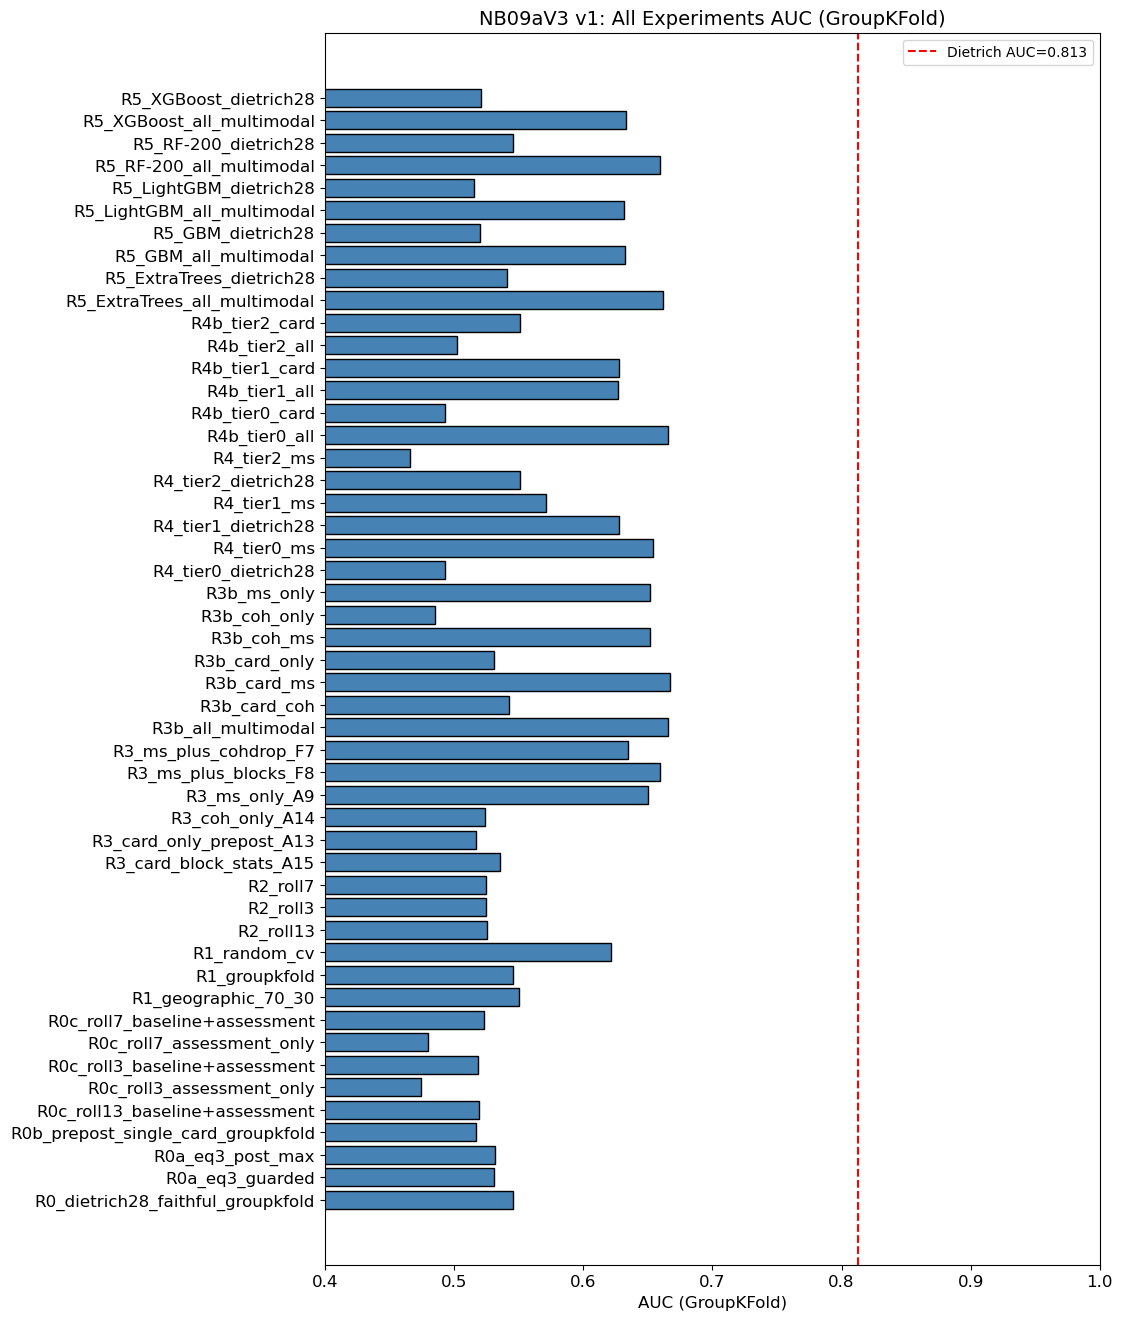

  Plot: cell_r6/all_experiments_auc_20260506_161546.png


In [18]:
# @title CELL R6: VALIDATION DIAGNOSTICS
import matplotlib.pyplot as plt

print("=" * 70)
print("CELL R6: VALIDATION DIAGNOSTICS")
print("=" * 70)

if not EXPERIMENT_LOG:
    print("  SKIP: no experiments logged yet")
else:
    print(f"\n  {'Experiment':50s} {'AUC':>6s} {'F1':>6s} {'P':>6s} {'R':>6s} {'nFeat':>6s}")
    print("  " + "-" * 80)
    for name, res in sorted(EXPERIMENT_LOG.items()):
        auc = res.get('auc_groupkfold', res.get('auc', 0))
        f1 = res.get('f1_groupkfold', 0)
        p = res.get('precision', 0)
        r = res.get('recall', 0)
        nf = res.get('n_features', 0)
        print(f"  {name:50s} {auc:6.3f} {f1:6.3f} {p:6.3f} {r:6.3f} {nf:6d}")

    best_exp = max(EXPERIMENT_LOG, key=lambda k: EXPERIMENT_LOG[k].get('auc_groupkfold', 0))
    best = EXPERIMENT_LOG[best_exp]
    if 'y_true' in best and 'groups' in best:
        print(f"\n  Per-city AUC ({best_exp}):")
        for city in sorted(np.unique(best['groups'])):
            mask = best['groups'] == city
            if len(np.unique(best['y_true'][mask])) > 1:
                city_auc = roc_auc_score(best['y_true'][mask], best['y_proba'][mask])
                print(f"    {city:25s} AUC={city_auc:.3f} (n={int(mask.sum())})")

    exp_names = sorted(EXPERIMENT_LOG.keys())
    aucs = [EXPERIMENT_LOG[n].get('auc_groupkfold', 0) for n in exp_names]
    fig, ax = plt.subplots(figsize=(10, max(4, len(exp_names) * 0.32)))
    ax.barh(exp_names, aucs, color='steelblue', edgecolor='black')
    ax.axvline(DIETRICH_PAPER['auc'], color='red', linestyle='--', linewidth=1.5,
               label=f"Dietrich AUC={DIETRICH_PAPER['auc']}")
    ax.set_xlabel('AUC (GroupKFold)')
    ax.set_xlim(0.4, 1.0)
    ax.legend()
    ax.set_title('NB09aV3 v1: All Experiments AUC (GroupKFold)')
    save_fig(fig, 'all_experiments_auc', 'cell_r6')

# CELL R7: FEATURE IMPORTANCE + SHAP (fusion_composite_blockstats F8)Permutation importance + SHAP top-20. SHAP is RAM-heavy; sampled to 2000 rows.Critical: watch for `was_observed_*` and any leakage pattern in SHAP top-10.

CELL R7: FEATURE IMPORTANCE + SHAP
  load_v2('fusion_composite_blockstats'): 62,043 rows, 415 cols, 19 cities


/home/alpineobotics/miniconda3/envs/bda/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/home/alpineobotics/miniconda3/envs/bda/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/home/alpineobotics/miniconda3/envs/bda/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. R

  Saved: cell_r7/permutation_importance_20260506_161952.csv (12.2 KB)

  Top-20 features (permutation importance):
    s2__composite__b02__post_winter_baseline                0.0000 +/- 0.0000
    s2__composite__ndwi__post_winter_baseline               0.0000 +/- 0.0000
    s2__composite__ndvi__post_winter_baseline               0.0000 +/- 0.0000
    s2__composite__ndre__post_winter_baseline               0.0000 +/- 0.0000
    s2__composite__ndwi__prebattle_baseline                 0.0000 +/- 0.0000
    s2__composite__b02__prebattle_baseline                  0.0000 +/- 0.0000
    s2__composite__mndwi__post_winter_baseline              0.0000 +/- 0.0000
    s2__composite__cire__post_winter_baseline               0.0000 +/- 0.0000
    s2__composite__mndwi__prebattle_baseline                0.0000 +/- 0.0000
    s1__vv__blk01__std                                      0.0000 +/- 0.0000
    s2__composite__ndwi__winter_baseline                    0.0000 +/- 0.0000
    s2__composite__ndre__wi

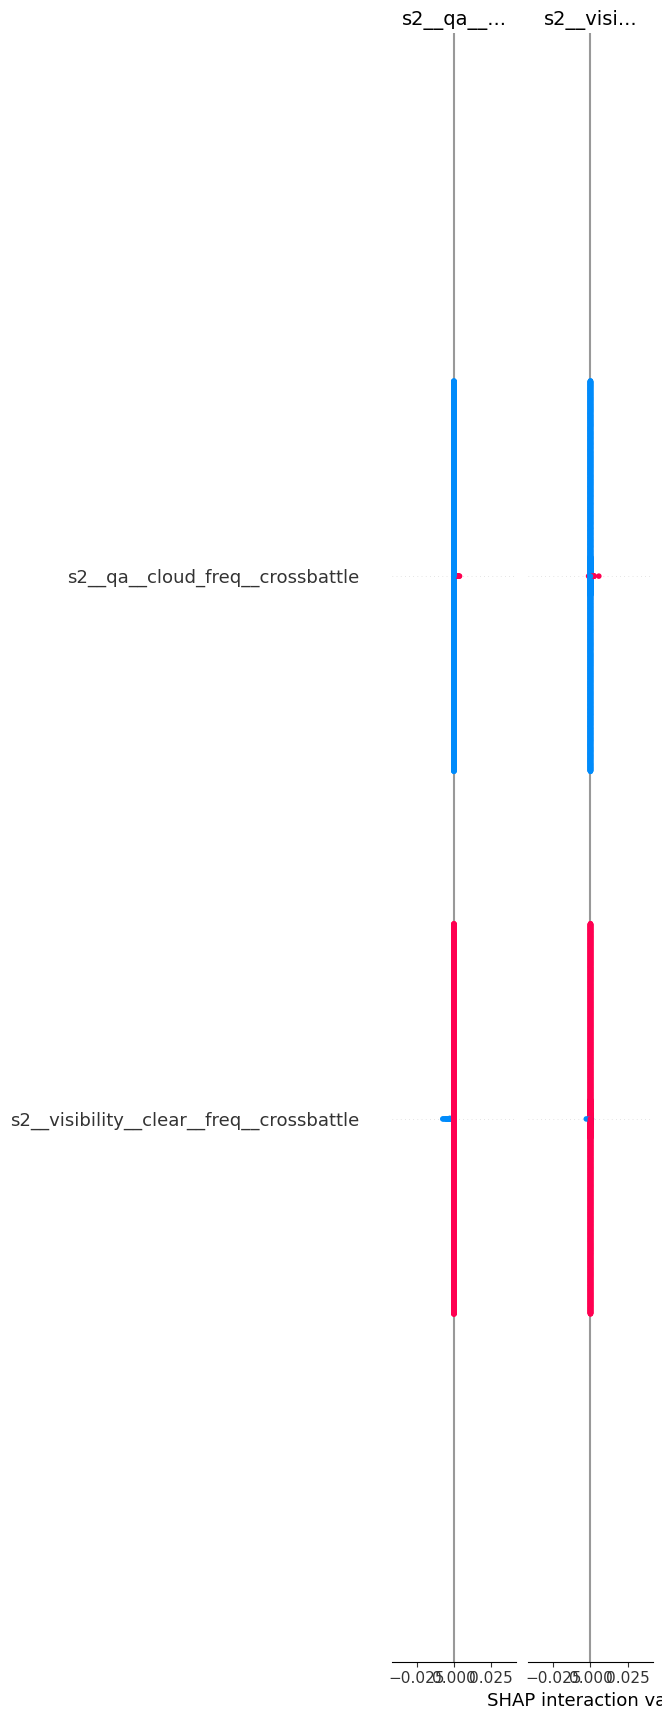

5270

In [19]:
# @title CELL R7: FEATURE IMPORTANCE + SHAP (F8 fusion_composite_blockstats)
from sklearn.inspection import permutation_importance

print("=" * 70)
print("CELL R7: FEATURE IMPORTANCE + SHAP")
print("=" * 70)

df_f8 = load_v2('fusion_composite_blockstats')
f8_info = MANIFEST['parquets']['fusion_composite_blockstats']
feat_cols = [c for c in f8_info['feature_columns'] if c in df_f8.columns]

result = prepare_features(df_f8, feat_cols)
if result:
    X, y, groups, building_ids, clean = result

    rf = RandomForestClassifier(**RF_PARAMS)
    rf.fit(X, y)

    gkf = GroupKFold(n_splits=min(N_FOLDS, len(np.unique(groups))))
    for tr, te in gkf.split(X, y, groups):
        perm_imp = permutation_importance(rf, X[te], y[te], n_repeats=10,
                                           random_state=RANDOM_STATE, n_jobs=-1, scoring='roc_auc')
        break

    imp_df = pd.DataFrame({'feature': clean,
                            'importance_mean': perm_imp.importances_mean,
                            'importance_std': perm_imp.importances_std,
                            }).sort_values('importance_mean', ascending=False)
    save_result(imp_df, 'permutation_importance', 'cell_r7')

    print(f"\n  Top-20 features (permutation importance):")
    for _, row in imp_df.head(20).iterrows():
        flag = ' [*was_observed*]' if row['feature'].startswith('was_observed') else ''
        print(f"    {row['feature']:55s} {row['importance_mean']:.4f} +/- {row['importance_std']:.4f}{flag}")

    try:
        import shap
        n_shap = min(2000, len(X))
        explainer = shap.TreeExplainer(rf)
        shap_values = explainer.shap_values(X[:n_shap])
        if isinstance(shap_values, list):
            shap_values = shap_values[1]
        print(f"\n  SHAP computed on {n_shap} samples")
        shap.summary_plot(shap_values, X[:n_shap], feature_names=clean, show=True, max_display=20)
    except ImportError:
        print("\n  SHAP not available (pip install shap)")
    except Exception as e:
        print(f"\n  SHAP error: {e}")

del df_f8
gc.collect()

# CELL R8: SAVE OOF PREDICTIONS + SUMMARYSaves every experiment's OOF predictions for downstream stacking (NB09c).Final summary table sorted by AUC.

In [20]:
# @title CELL R8: SAVE OOF PREDICTIONS + SUMMARY

print("=" * 70)
print("CELL R8: SAVE OOF PREDICTIONS + SUMMARY")
print("=" * 70)

RESULTS_DIR = OUT_DIR

results_summary = {}
for name, res in EXPERIMENT_LOG.items():
    summary = {k: v for k, v in res.items()
               if k not in ('y_true', 'y_proba', 'y_pred', 'groups', 'fold_aucs', 'fold_f1s')}
    if 'fold_aucs' in res:
        summary['fold_aucs'] = [float(x) for x in res['fold_aucs']]
    results_summary[name] = summary
save_result(results_summary, 'experiment_log', 'cell_r8', fmt='json')

# --- CANONICAL OOF DIR (v5): matches NB07/NB08/NB08b pattern ------------
# NB12a/NB12b/NB12c rglob RESULTS_ROOT for oof_predictions/oof_*.parquet.
# Keeping OOF here (under results/, not under data/outputs/) is required for discovery.
OOF_DIR = RESULTS_ROOT / 'nb09a_v3' / 'oof_predictions'
OOF_DIR.mkdir(parents=True, exist_ok=True)
print(f"  OOF_DIR (canonical): {OOF_DIR}")
oof_count = 0
for name, res in EXPERIMENT_LOG.items():
    if 'y_true' in res and 'y_proba' in res and len(res['y_true']) > 0:
        variant = name.split('_', 1)[0] if '_' in name else ''
        out = save_oof_from_result(res, model_id=name, oof_dir=OOF_DIR,
                                    variant_id=f'nb09a;cell={variant}')
        if out is not None:
            oof_count += 1
print(f"  Saved: {oof_count} OOF prediction parquets -> {OOF_DIR}")

# OOF inventory (for NB12a discovery)
oof_files = sorted(OOF_DIR.glob('oof_*.parquet'))
if oof_files:
    inv_rows = []
    for p in oof_files:
        head = pd.read_parquet(p, columns=['model_id', 'variant_id', 'cm_class'])
        cm = head['cm_class'].value_counts()
        inv_rows.append({
            'file':       p.name,
            'model_id':   head['model_id'].iloc[0],
            'variant_id': head['variant_id'].iloc[0],
            'n_rows':     len(head),
            'TP':         int(cm.get('TP', 0)),
            'FN':         int(cm.get('FN', 0)),
            'FP':         int(cm.get('FP', 0)),
            'TN':         int(cm.get('TN', 0)),
        })
    inv_df = pd.DataFrame(inv_rows)
    save_result(inv_df, 'nb09a_oof_inventory', 'cell_r8')
    print(f"  OOF inventory: {len(oof_files)} parquets")

summary_rows = []
for name, res in sorted(EXPERIMENT_LOG.items(), key=lambda x: -x[1].get('auc_groupkfold', 0)):
    summary_rows.append({
        'experiment': name,
        'auc': res.get('auc_groupkfold', 0),
        'f1': res.get('f1_groupkfold', 0),
        'precision': res.get('precision', 0),
        'recall': res.get('recall', 0),
        'n_features': res.get('n_features', 0),
        'n_buildings': res.get('n_buildings', 0),
        'n_cities': res.get('n_cities', 0),
    })
if summary_rows:
    save_result(pd.DataFrame(summary_rows), 'experiment_summary', 'cell_r8')

print(f"\n  {'Experiment':50s} {'AUC':>6s}")
print("  " + "-" * 60)
for name, res in sorted(EXPERIMENT_LOG.items(), key=lambda x: -x[1].get('auc_groupkfold', 0)):
    auc = res.get('auc_groupkfold', 0)
    print(f"  {name:50s} {auc:6.3f}")

print(f"\n  Dietrich paper: AUC={DIETRICH_PAPER['auc']}")
print(f"  Results saved to: {OUT_DIR}")

# finalize registry
try:
    registry.save()
except Exception as e:
    print(f"  registry.save() error: {e}")

CELL R8: SAVE OOF PREDICTIONS + SUMMARY
  Saved: cell_r8/experiment_log_20260506_170703.json (36.5 KB)
  OOF_DIR (canonical): /content/drive_f/masterthesis/results/nb09a_v3/oof_predictions
    saved oof -> oof_R0_dietrich28_faithful_groupkfold__20260506_142934_7bcb82.parquet  TP=21 FN=8226 FP=44 TN=54952
    [save_oof] skipped R0a_eq3_guarded: missing keys (need ('y_true', 'y_proba', 'groups', 'point_id', 'fold_id'))
    [save_oof] skipped R0a_eq3_post_max: missing keys (need ('y_true', 'y_proba', 'groups', 'point_id', 'fold_id'))
    saved oof -> oof_R0b_prepost_single_card_groupkfold__20260506_142934_7bcb82.parquet  TP=111 FN=8136 FP=397 TN=54599
    saved oof -> oof_R0c_roll3_baseline+assessment__20260506_142934_7bcb82.parquet  TP=12 FN=8235 FP=29 TN=54967
    saved oof -> oof_R0c_roll3_assessment_only__20260506_142934_7bcb82.parquet  TP=2265 FN=5982 FP=18048 TN=36948
    saved oof -> oof_R0c_roll7_baseline+assessment__20260506_142934_7bcb82.parquet  TP=13 FN=8234 FP=29 TN=54967
   